# Maths in Neural Networks

**Introduction**

I’ve tried several times to understand the mathematics behind neural networks and how they are trained. Each time, I manage to grasp parts of it, but after a few weeks much of that understanding fades. There are several reasons for this:

* The equations and notation can be quite complex.
* Different books and videos often use different symbols and formulations.
* I struggled to find an effective way to study the material — whether to simply read, work through equations by hand, or jump straight into coding examples.

**Goal**

The main goal of this project is to share the parts I personally found difficult to grasp — the common "gotchas".
Rather than attempting yet another comprehensive explanation, I’ll focus on highlighting the tricky aspects, since there are already many excellent resources that cover the full theory.

In [25]:
%matplotlib inline

In [26]:
import math

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import Image

## Function Vectorization

Key Ideas

* Most standard functions are written to work with single values. In software engineering, if we want them to process many values, we usually add a loop inside the function.
* In machine learning, functions often appear to operate on a single value, but in practice they are applied to entire vectors or matrices of values at once.

Two examples to showcase the ideas above.

In [27]:
# Most NumPy functions (such as `np.exp`) are already vectorized, meaning they automatically work with arrays without requiring loops.

def sigmoid(z):
    return 1. / (1. + np.exp(-z))

In [28]:
# We can convert a scalar function so it works on arrays using `np.vectorize()`. Rarely needed in practice.

def square(x):
    return x**2

square = np.vectorize(square)
arr = np.array([1, 2, 3, 4])
square(arr)

array([ 1,  4,  9, 16])

Most textbook equations follow the same pattern—you don’t immediately know what kind of object a symbol represents or what shape it has. I’ve found it helpful to write down the shapes (e.g. by using draw.io). Example below is from Géron [3].

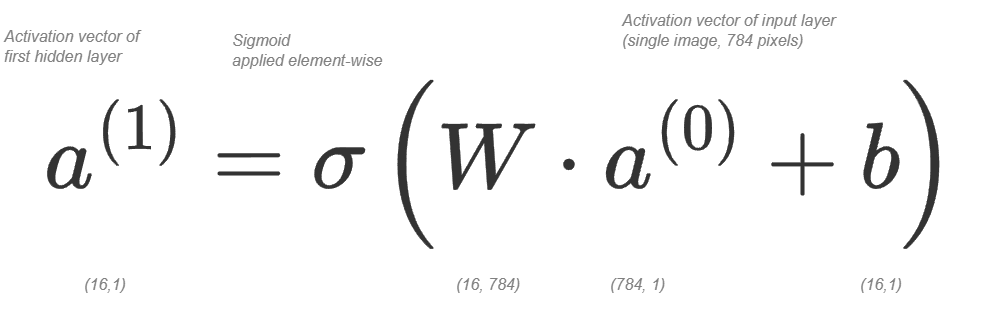

In [29]:
Image(filename='images/02.png', width=800)

## Neurons Types

Neural network explanations often mention several foundational neuron models: TLU, Perceptron, and Adaline. I struggled to understand the difference between them.

All of them are single‑unit (or single‑layer) abstractions inspired by biological neurons, computing a weighted sum of inputs.

**Historical progression**

- The TLU (1943) introduced the basic idea but had no learning — weights were set by hand.
- The Perceptron (1958) added an automatic learning rule.
- Adaline (1960) refined it so that weight updates use the continuous linear output rather than the thresholded prediction.

**Output behavior**

- TLU: binary output
- Perceptron: binary output
- Adaline: uses a continuous output during training for weight updates, but still applies a threshold to produce a binary prediction

**Learning characteristics**

- TLU: no learning mechanism — weights were manually configured
- Perceptron: updates weights based on binary classification errors
- Adaline: updates weights based on continuous error values, enabling smoother and more efficient optimization

**Error handling**

The Perceptron updates only when it misclassifies, whereas Adaline measures how far off the continuous prediction is, allowing more precise weight adjustments.

## Vectors as Matrices

In ML, vectors are often treated as matrices so that linear algebra operations like matrix multiplication work consistently. Although mathematically a vector of size n can be written simply as `(n,)`, many ML implementations treat it as a column matrix of shape `(n,1)`.

In [30]:
W = np.arange(1, 10).reshape((3,3))
x = np.array([2, -1, 4])

W, x, W @ x

(array([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]]),
 array([ 2, -1,  4]),
 array([12, 27, 42]))

In [31]:
W = np.arange(1, 10).reshape((3,3))
x = np.array([2, -1, 4]).reshape(-1, 1)

W, x, W @ x

(array([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]]),
 array([[ 2],
        [-1],
        [ 4]]),
 array([[12],
        [27],
        [42]]))

## Layer Activations Formulas

Calculating the activation of a layer based on the preceding layer can be confusing, especially since different authors use different conventions for matrix orientation.

To clear this up, I have compared the equations used by Géron [1] and 3Blue1Brown [3]. To make these abstract formulas more concrete, I used a dataset - the classical [MNIST](https://en.wikipedia.org/wiki/MNIST_database). First equation to calculate the hidden layer activations is Géron's [1] (it contains all training examples), next comes 3Blue1Brown [3] and is for a single instance. At a glance:
- Géron [1]: Uses a vectorized approach designed for the entire training set at once. Mini-batch can also be used.
- 3Blue1Brown [3]: Focuses on the intuition of a single training instance.

Pay close attention to the symbols and the order of multiplication. The comments on the diagrams below provide a deeper dive into how these two notations differ from one another.

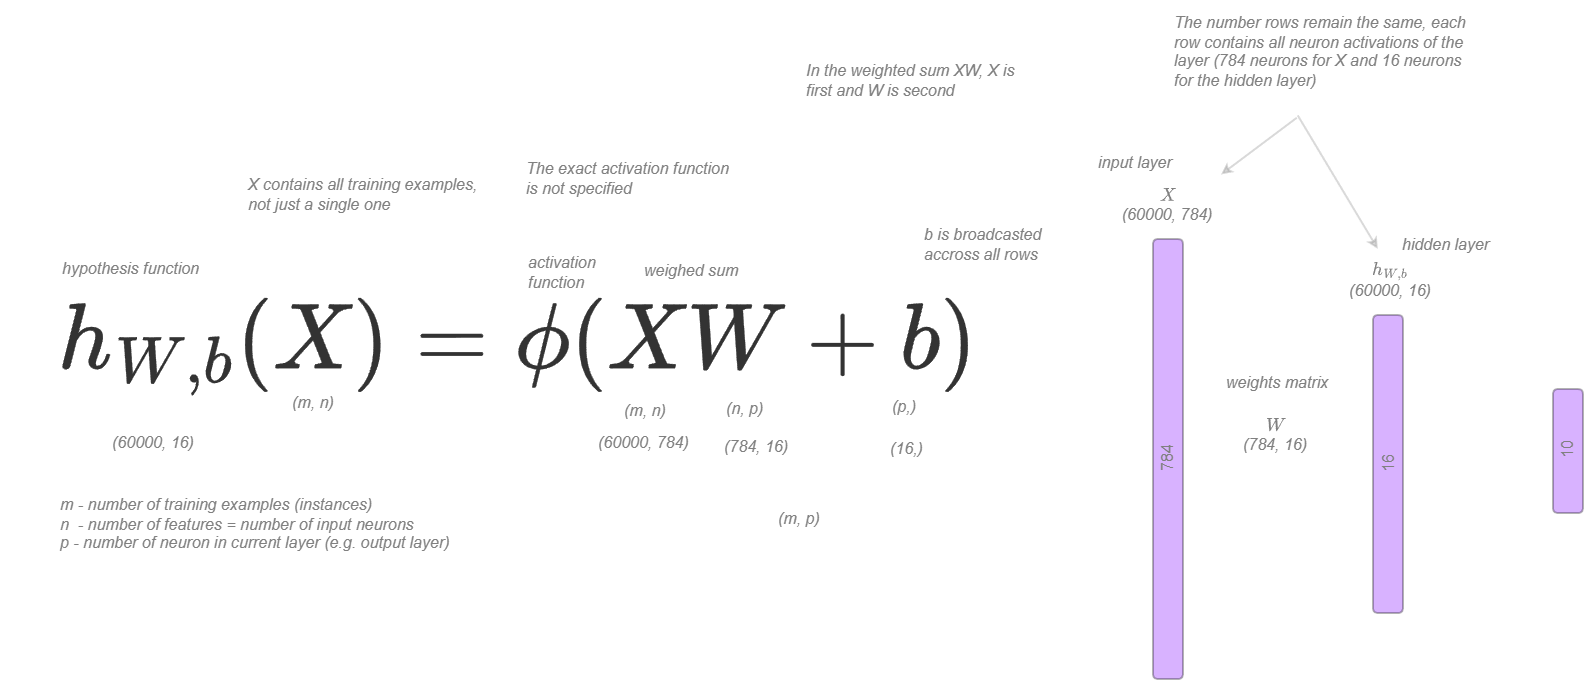

In [32]:
Image(filename='images/01.png', width=1200)

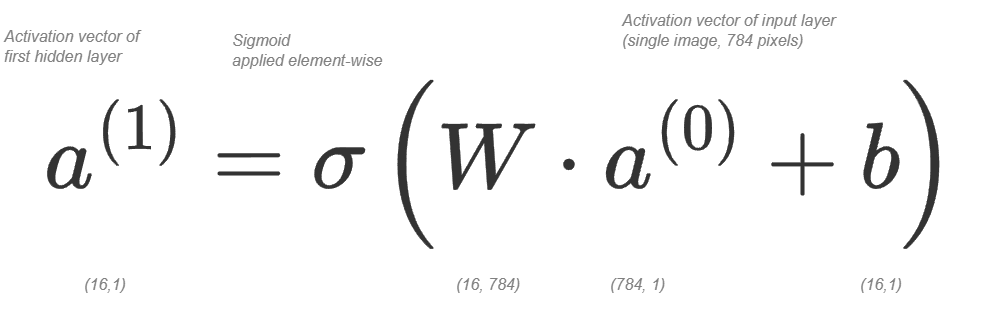

In [33]:
Image(filename='images/02.png', width=800)

## Compute Derivatives

How do computers compute derivatives, which are needed to update neural network parameters?

Generally, there are four main approaches:

1. Manual: Deriving the derivative formula manually using calculus rules
2. Numerical: Approximating the derivative using the difference formula
3. Symbolic: Applying symbolic differentiation rules automatically, similar to manual calculus but performed by software
4. AutoDiff: Using Automatic Differentiation, with backpropagation being the version used in neural networks

Let's see an example:

$$y = \ln(x_1) + x_1 x_2 - \sin(x_2)$$

and we want $$\frac{\partial{y}}{\partial{x_1}} \text{ at } x_1 = 2, x_2 = 5$$

True derivative at those values is:
$$\frac{\partial{y}}{\partial{x_1}} = \frac{1}{x_1} + x_2 = \frac{1}{2} + 5 = 5.5$$

**Manual**

Differentiate term by term. We then use the derivative formula DIRECTLY in the code.

$$\frac{\partial}{\partial x_1}\bigl[\ln x_1\bigr] = \frac{1}{x_1}, \quad \frac{\partial}{\partial x_1}\bigl[x_1 x_2\bigr] = x_2, \quad \frac{\partial}{\partial x_1}\bigl[\sin x_2\bigr] = 0$$

$$\boxed{\frac{\partial y}{\partial x_1} = \frac{1}{x_1} + x_2}$$

In [34]:
def manual(x1, x2):
    return 1/x1 + x2

manual(2.0, 5.0)

5.5

**Numerical**

$$\frac{\partial y}{\partial x_1} \approx \frac{f(x_1 + h,\ x_2) - f(x_1,\ x_2)}{h}$$

In [35]:
def f(x1, x2):
    return np.log(x1) + x1*x2 - np.sin(x2)

def numerical(x1, x2, h=1e-5):
    return (f(x1+h, x2) - f(x1, x2)) / h

numerical(2.0, 5.0)

np.float64(5.4999987499471095)

**Symbolic**

Manipulates the expression algebraically and returns an exact formula.

In [36]:
x1, x2 = sp.symbols('x1 x2')
f = sp.ln(x1) + x1*x2 - sp.sin(x2)

df = sp.diff(f, x1)
print(df)
print(df.subs({x1: 2, x2: 5}))

x2 + 1/x1
11/2


**AutoDiff**

All sources provide some explanation of backpropagation. I found

1. Create the computation graph — break the expression into primitive operations, each node is one operation
2. Assign intermediate variables (v1, v2, ...) one per node in the forward pass
3. Solve local derivatives by hand — for each node, derive the simple local gradient (e.g. d(ln x)/dx = 1/x)
4. Seed the backward pass — set dy/dy = 1
5. Walk the graph in reverse — multiply local gradients by the incoming gradient (chain rule), propagating back toward the inputs
6. Accumulate at inputs — if a variable (like x1) feeds into multiple nodes, sum all gradient contributions

Key gotchas:
- the derivatives must be propagated at each step, to
- the simple local derivatives are calulated symbolically and added to the code

```mermaid
graph LR
    x1(["x₁"])
    x2(["x₂"])

    v1["v₁ = ln(x₁)"]
    v2["v₂ = x₁ · x₂"]
    v3["v₃ = v₁ + v₂"]
    v4["v₄ = sin(x₂)"]
    y(["y = v₃ − v₄"])

    x1 --> v1
    x1 --> v2
    x2 --> v2
    x2 --> v4
    v1 --> v3
    v2 --> v3
    v3 --> y
    v4 --> y
```

In [37]:
def backward(x1, x2):
    # Forward pass
    v1 = math.log(x1)
    v2 = x1 * x2
    v3 = v1 + v2
    v4 = math.sin(x2)
    y  = v3 - v4

    # Backward pass
    d_y__d_y  = 1.0

    # y = v3 - v4
    d_y__d_v3 = d_y__d_y * 1.0
    d_y__d_v4 = d_y__d_y * -1.0

    # v3 = v1 + v2
    d_y__d_v1 = d_y__d_v3 * 1.0
    d_y__d_v2 = d_y__d_v3 * 1.0

    # v2 = x1 * x2,  v1 = ln(x1)
    d_y__d_x1 = (d_y__d_v1 * (1/x1)) + (d_y__d_v2 * x2)

    return d_y__d_x1


x1, x2 = 2.0, 5.0
dy_dx1 = backward(x1, x2)

print(f"dy/dx1 (autodiff) = {dy_dx1:.6f}")
print(f"dy/dx1 (analytic) = {1/x1 + x2:.6f}")

dy/dx1 (autodiff) = 5.500000
dy/dx1 (analytic) = 5.500000


I also found it quite useful to debug the code from [2] Raschka; it is [publicly avalable at GitHub [5]](https://github.com/rasbt/machine-learning-book/blob/main/ch11/neuralnet.py). I paste a snippet, the complete drawio diagram is available in the project files.

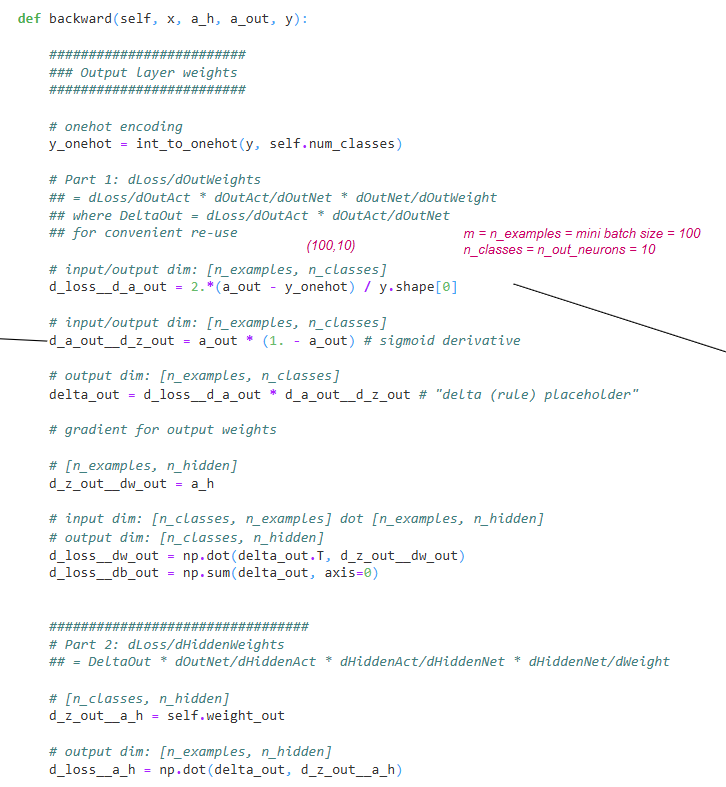

In [38]:
Image(filename='images/03.png', width=800)

An AI-generated good short explanation of backprop.


Let’s look at a chain of operations: $a \to b \to c \to L$.

Forward Mode (Finding $\frac{\partial L}{\partial a}$)

1. How does $b$ change with $a$? $\to \frac{\partial b}{\partial a}$
2. How does $c$ change with $a$? $\to \frac{\partial c}{\partial b} \cdot \frac{\partial b}{\partial a}$
3. How does $L$ change with $a$? $\to \frac{\partial L}{\partial c} \cdot \frac{\partial c}{\partial b} \cdot \frac{\partial b}{\partial a}$

Repeat this entire sequence for every single input weight.

Reverse Mode (Backprop)

1. Start at the end: $\frac{\partial L}{\partial L} = 1$.
2. Move back: $\frac{\partial L}{\partial c} = 1 \cdot \frac{\partial L}{\partial c}$ (Save this value!)
3. Move back: $\frac{\partial L}{\partial b} = \frac{\partial L}{\partial c} \cdot \frac{\partial c}{\partial b}$ (Use the saved value!)
4. Move back: $\frac{\partial L}{\partial a} = \frac{\partial L}{\partial b} \cdot \frac{\partial b}{\partial a}$ (Use the saved value!)

In one trip, you’ve calculated the gradient for $a, b,$ and $c$.


Finally, a brief summary of all four methods:
- Manual: 5.5 — exact, done by hand
- Numerical: 5.49999… — approximate, one call per parameter
- Symbolic: 11/2 = 5.5 — exact, but expression size explodes with depth
- AutoDiff: 5.5 — exact, all gradients in one backward pass

## NN from Scratch

I refined the custom neural network from [2] to better understand the backprop algorithm. My process involved using the repository found at [5] and documenting the debugging steps in the `notes.drawio` file.

To deepen my understanding, I adapted the code for two additional binary classification datasets with input features different from MNIST. I chose to use standalone .py files rather than Jupyter notebooks because a unified file structure is more compatible with IDE debugging tools than fragmented notebook cells.

These .py files are ready to run. The primary goal is to configure the network for new data structures.

**Blood Transfusion Service Center**

This dataset is the first classification one that showed up in OpenML [6].

The following modifications were necessary to integrate this dataset:
- Develop a new preprocessing pipeline.
- Replace MSE loss function with Binary Cross Entropy.
- Recalculat the backpropagation derivative formulas to match the new loss function.
- Adjust model hyperparameters, including layer dimensions, epoch counts, and learning rate.

These changes are contained within the `blood_transfusion.py` file.

**Iris**

Then I also configured the network for the iris dataset: see `iris.py`. Similar changes were needed as in the blood transfusion dataset.

## Activation Functions

An activation function takes a real number of any magnitude and maps it into a limited range such as [0, 1]. For example, it might turn 5.2 into 0.72 or 130 into 0.98. This is a useful way to think about what it does.

In practice, the function receives the net input of a neuron (the weighted sum of its inputs) and constrains that value to a fixed interval. Depending on the specific function, that interval might be 0 to 1 or −1 to 1. The function also usually doesn't receive a single value but rather a vector or matrix (for multiple neuron and training examples).


Why is this necessary? There are two main reasons:

- It keeps the neuron’s output within a manageable range, preventing values from growing uncontrollably as they pass through many layers.
- More importantly, it introduces non‑linearity. Without a non‑linear activation, the entire network would behave like a single linear transformation, making it unable to learn complex patterns.

Most sources on the topic describe the different activation functions well. For me, the key idea was simply understanding why we need them. The functions themselves are quite similar, and some are just more effective in certain situations. I didn’t explore the details further at this stage.

Finally, plotting some of the functions.

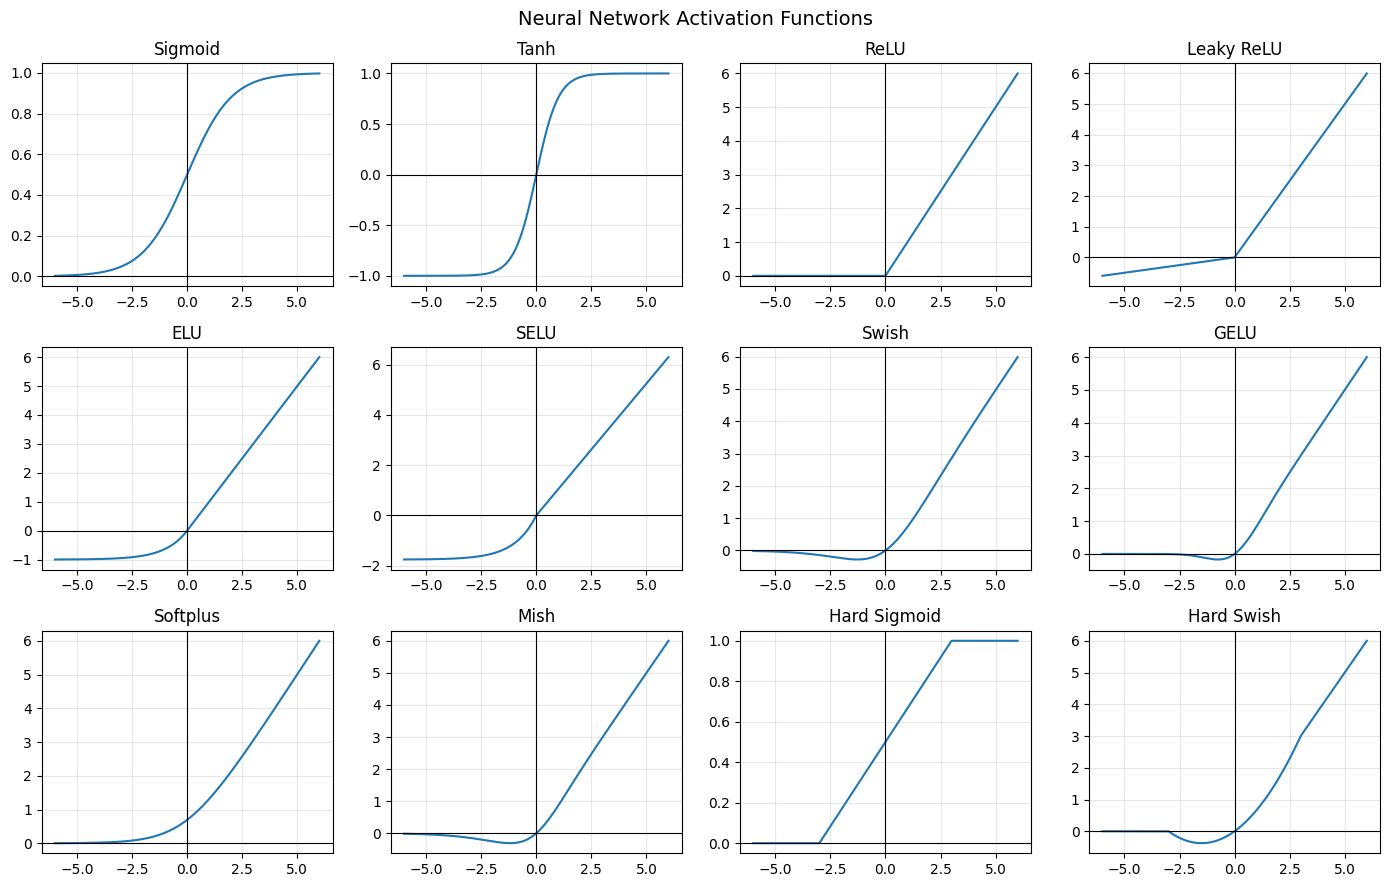

In [39]:
x = np.linspace(-6, 6, 500)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.1):
    return np.where(x >= 0, x, alpha * x)

def elu(x, alpha=1.0):
    return np.where(x >= 0, x, alpha * (np.exp(x) - 1))

def selu(x):
    lam, alpha = 1.0507, 1.67326
    return lam * np.where(x >= 0, x, alpha * (np.exp(x) - 1))

def swish(x):
    return x * sigmoid(x)

def gelu(x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

def softplus(x):
    return np.log1p(np.exp(x))

def mish(x):
    return x * np.tanh(softplus(x))

def hard_sigmoid(x):
    return np.clip((x + 3) / 6, 0, 1)

def hard_swish(x):
    return x * hard_sigmoid(x)

activations = [
    ("Sigmoid",      sigmoid(x)),
    ("Tanh",         tanh(x)),
    ("ReLU",         relu(x)),
    ("Leaky ReLU",   leaky_relu(x)),
    ("ELU",          elu(x)),
    ("SELU",         selu(x)),
    ("Swish",        swish(x)),
    ("GELU",         gelu(x)),
    ("Softplus",     softplus(x)),
    ("Mish",         mish(x)),
    ("Hard Sigmoid", hard_sigmoid(x)),
    ("Hard Swish",   hard_swish(x)),
]

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle("Neural Network Activation Functions", fontsize=14)

for ax, (name, y_vals) in zip(axes.flat, activations):
    ax.plot(x, y_vals)
    ax.set_title(name)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## References

[1] Géron, A. (2019). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (2nd ed.). O’Reilly Media.

[2] Raschka, S. (2022). *Machine learning with PyTorch and Scikit-Learn*. Packt Publishing.

[3] 3Blue1Brown (accessed 2026-03-06) *Neural networks*. https://www.3blue1brown.com/topics/neural-networks

[4] Baydin, A. G., & Pearlmutter, B. A. (2014). Automatic differentiation of algorithms for machine learning. arXiv preprint arXiv:1404.7456. https://arxiv.org/abs/1404.7456

[5] Raschka, S. (accessed 2026-03-08) (Version main) [Computer software]. GitHub. https://github.com/rasbt/machine-learning-book/tree/main/ch11

[6] OpenML. (n.d.). Blood Transfusion Service Center (Version 1) [Data set]. OpenML. https://www.openml.org/search?type=data&sort=runs&id=1464&status=active